# Perturbation Performance vs. Number of Perturbed Genes

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc
import scvi

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features
from perturb_utils import load_crc_slide, compute_cf_logfc

plt.rcParams['figure.dpi'] = 100
scvi.settings.seed = 0
print(cellina.__version__)


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

0.6.1


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id             = 242
labels_key           = 'coarse_type'
domains_key          = 'typ'
top_n                = 100                        # metric evaluation window (fixed)
top_n_perturb_values = [10, 20, 50, 100, 200, 500, 1000] # sweep
batch_size           = 512
min_cells            = 50
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_ID'
library_size     = 'latent'

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

## 1. Data

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [4]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)

## 2. Model

In [ ]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x',
)

model = CellinaModel(
    adata,
    n_latent=20,
    classifier_lambda=1,
    discriminator_lambda=1,
    condition_on_intrinsic=False,
)

INFO     Generating sequential column names                                                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [ ]:
model.train(
    max_epochs=100,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=10,
    early_stopping_monitor='vae_loss_validation',
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={'lr': 1e-3, 'weight_decay': 0.0001, 'normalize_losses': True},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[0],
)

model.save(save_path, overwrite=True)

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
INFO: GPU available: True (cuda), used: True
2026-03-31 08:48:19 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-03-31 08:48:19 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-03-31 08:48:19 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_ma

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 10 records. Best score: 592.988. Signaling Trainer to stop.


## 3. Pseudobulk logFC — Global & Cell-type-specific

In [7]:
model = CellinaModel.load(save_path, adata)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-03-31 09:29:39 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File results/perturb_loo/trained/crc_242_ID/model.pt already downloaded                                   


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [8]:
# Global: all cells pooled together
pdata_global = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_global, target_sum=1e4)
sc.pp.log1p(pdata_global)

global_logfc_series = pd.Series(
    (pdata_global[pdata_global.obs[domains_key] == crc_label].X
     - pdata_global[pdata_global.obs[domains_key] == ref_label].X).flatten(),
    index=pdata_global.var_names,
)

# Cell-type-specific
pdata_ct = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_ct, target_sum=1e4)
sc.pp.log1p(pdata_ct)

cell_types_with_both = [
    ct for ct in pdata_ct.obs[labels_key].unique()
    if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
    and ((pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (pdata_ct[(pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)].X
             - pdata_ct[(pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata_ct.var_names,
            name=ct,
        )
        for ct in cell_types_with_both
    ],
    axis=1,
).T

print(f"Global logFC: {global_logfc_series.shape[0]} genes")
print(f"CT-specific logFC: {domain_logfc_df.shape} (cell types × genes)")

Global logFC: 3000 genes
CT-specific logFC: (8, 3000) (cell types × genes)


## 4. Pre-compute Fixed Expressions per Cell Type

In [9]:
import scanpy as sc  # needed for sc.pp calls above in case not imported

ref_idxs = {}   # ct → indices in REF
crc_idxs = {}   # ct → indices in CRC
ref_exprs = {}  # ct → (n_ref, n_genes)
cf_exprs  = {}  # ct → (n_crc, n_genes)  real CRC, ground truth
swap_exprs = {} # ct → (n_ref, n_genes)  counterfactual (graph swap)

cell_types = []
for ct in sorted(cell_types_with_both):
    ref_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    )[0]
    crc_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == crc_label)
    )[0]
    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue
    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
    ref_idxs[ct]  = ref_idx
    crc_idxs[ct]  = crc_idx
    ref_exprs[ct]  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    cf_exprs[ct]   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)
    swap_exprs[ct] = model.get_counterfactual_expression(ref_idx, crc_idx, batch_size=batch_size, library_size=library_size)
    cell_types.append(ct)

print(f"\nEvaluating {len(cell_types)} cell types: {cell_types}")

  Endothelial: ref=982, crc=1642
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Epithelial: ref=19472, crc=53313


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  Fibroblast: ref=6100, crc=22548
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Mast_cell: ref=795, crc=383


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  T_cell: ref=4580, crc=3245


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        

Evaluating 8 cell types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


## 5. Counterfactual Baseline (Fixed)

In [10]:
cf_pearson_vals = []
cf_edist_vals = []
for ct in cell_types:
    stats = compute_cf_logfc(ref_exprs[ct], swap_exprs[ct], cf_exprs[ct], top_n=top_n)
    cf_pearson_vals.append(stats['pearson_r'])
    cf_edist_vals.append(stats['edistance'])

cf_avg_pearson = float(np.mean(cf_pearson_vals))
cf_avg_edistance = float(np.mean(cf_edist_vals))
print(f"Counterfactual avg Pearson r   = {cf_avg_pearson:.3f}")
print(f"Counterfactual avg edistance   = {cf_avg_edistance:.4f}")

Counterfactual avg Pearson r   = 0.835
Counterfactual avg edistance   = 3.9795


## 6. Sweep: Global vs Cell-type-specific

In [11]:
global_results = []
ctspec_results = []
global_edist_results = []
ctspec_edist_results = []

for n in top_n_perturb_values:
    print(f"\n── top_n_perturb = {n} ──")

    # ── Global perturbation ──────────────────────────────────────────────────
    top_genes = global_logfc_series.abs().nlargest(n).index.tolist()
    logfc_dict = {g: float(global_logfc_series[g]) for g in top_genes}
    make_neighbor_perturbation(adata, perturbations=logfc_dict, obsm_key_out='spatial_x_cf', base=np.e)

    pearson_vals = []
    edist_vals = []
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_cf_logfc(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        pearson_vals.append(stats['pearson_r'])
        edist_vals.append(stats['edistance'])
    avg_g = float(np.mean(pearson_vals))
    avg_g_edist = float(np.mean(edist_vals))
    global_results.append(avg_g)
    global_edist_results.append(avg_g_edist)
    print(f"  global:      Pearson r = {avg_g:.3f}  edistance = {avg_g_edist:.4f}")

    # ── Cell-type-specific perturbation ──────────────────────────────────────
    logfc_series_dict = {}
    for ct in domain_logfc_df.index:
        s = domain_logfc_df.loc[ct]
        top_g = s.abs().nlargest(n).index.tolist()
        logfc_series_dict[ct] = s[top_g]
    make_neighbor_perturbation(
        adata, perturbations=logfc_series_dict, groupby=labels_key,
        obsm_key_out='spatial_x_cf', base=np.e,
    )

    pearson_vals = []
    edist_vals = []
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_cf_logfc(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        pearson_vals.append(stats['pearson_r'])
        edist_vals.append(stats['edistance'])
    avg_c = float(np.mean(pearson_vals))
    avg_c_edist = float(np.mean(edist_vals))
    ctspec_results.append(avg_c)
    ctspec_edist_results.append(avg_c_edist)
    print(f"  CT-specific: Pearson r = {avg_c:.3f}  edistance = {avg_c_edist:.4f}")

# clean up temporary obsm key
if 'spatial_x_cf' in adata.obsm:
    del adata.obsm['spatial_x_cf']


── top_n_perturb = 10 ──
  global:      Pearson r = 0.598  edistance = 5.7679
  CT-specific: Pearson r = 0.634  edistance = 5.7423

── top_n_perturb = 20 ──
  global:      Pearson r = 0.716  edistance = 4.9861
  CT-specific: Pearson r = 0.661  edistance = 4.9574

── top_n_perturb = 50 ──
  global:      Pearson r = 0.764  edistance = 4.6213
  CT-specific: Pearson r = 0.734  edistance = 4.6384

── top_n_perturb = 100 ──
  global:      Pearson r = 0.783  edistance = 4.6730
  CT-specific: Pearson r = 0.750  edistance = 4.7438

── top_n_perturb = 200 ──
  global:      Pearson r = 0.786  edistance = 4.9250
  CT-specific: Pearson r = 0.764  edistance = 4.7416

── top_n_perturb = 500 ──
  global:      Pearson r = 0.788  edistance = 4.9997
  CT-specific: Pearson r = 0.773  edistance = 4.8930

── top_n_perturb = 1000 ──
  global:      Pearson r = 0.787  edistance = 5.1712
  CT-specific: Pearson r = 0.768  edistance = 4.9923


## 7. Summary Plot

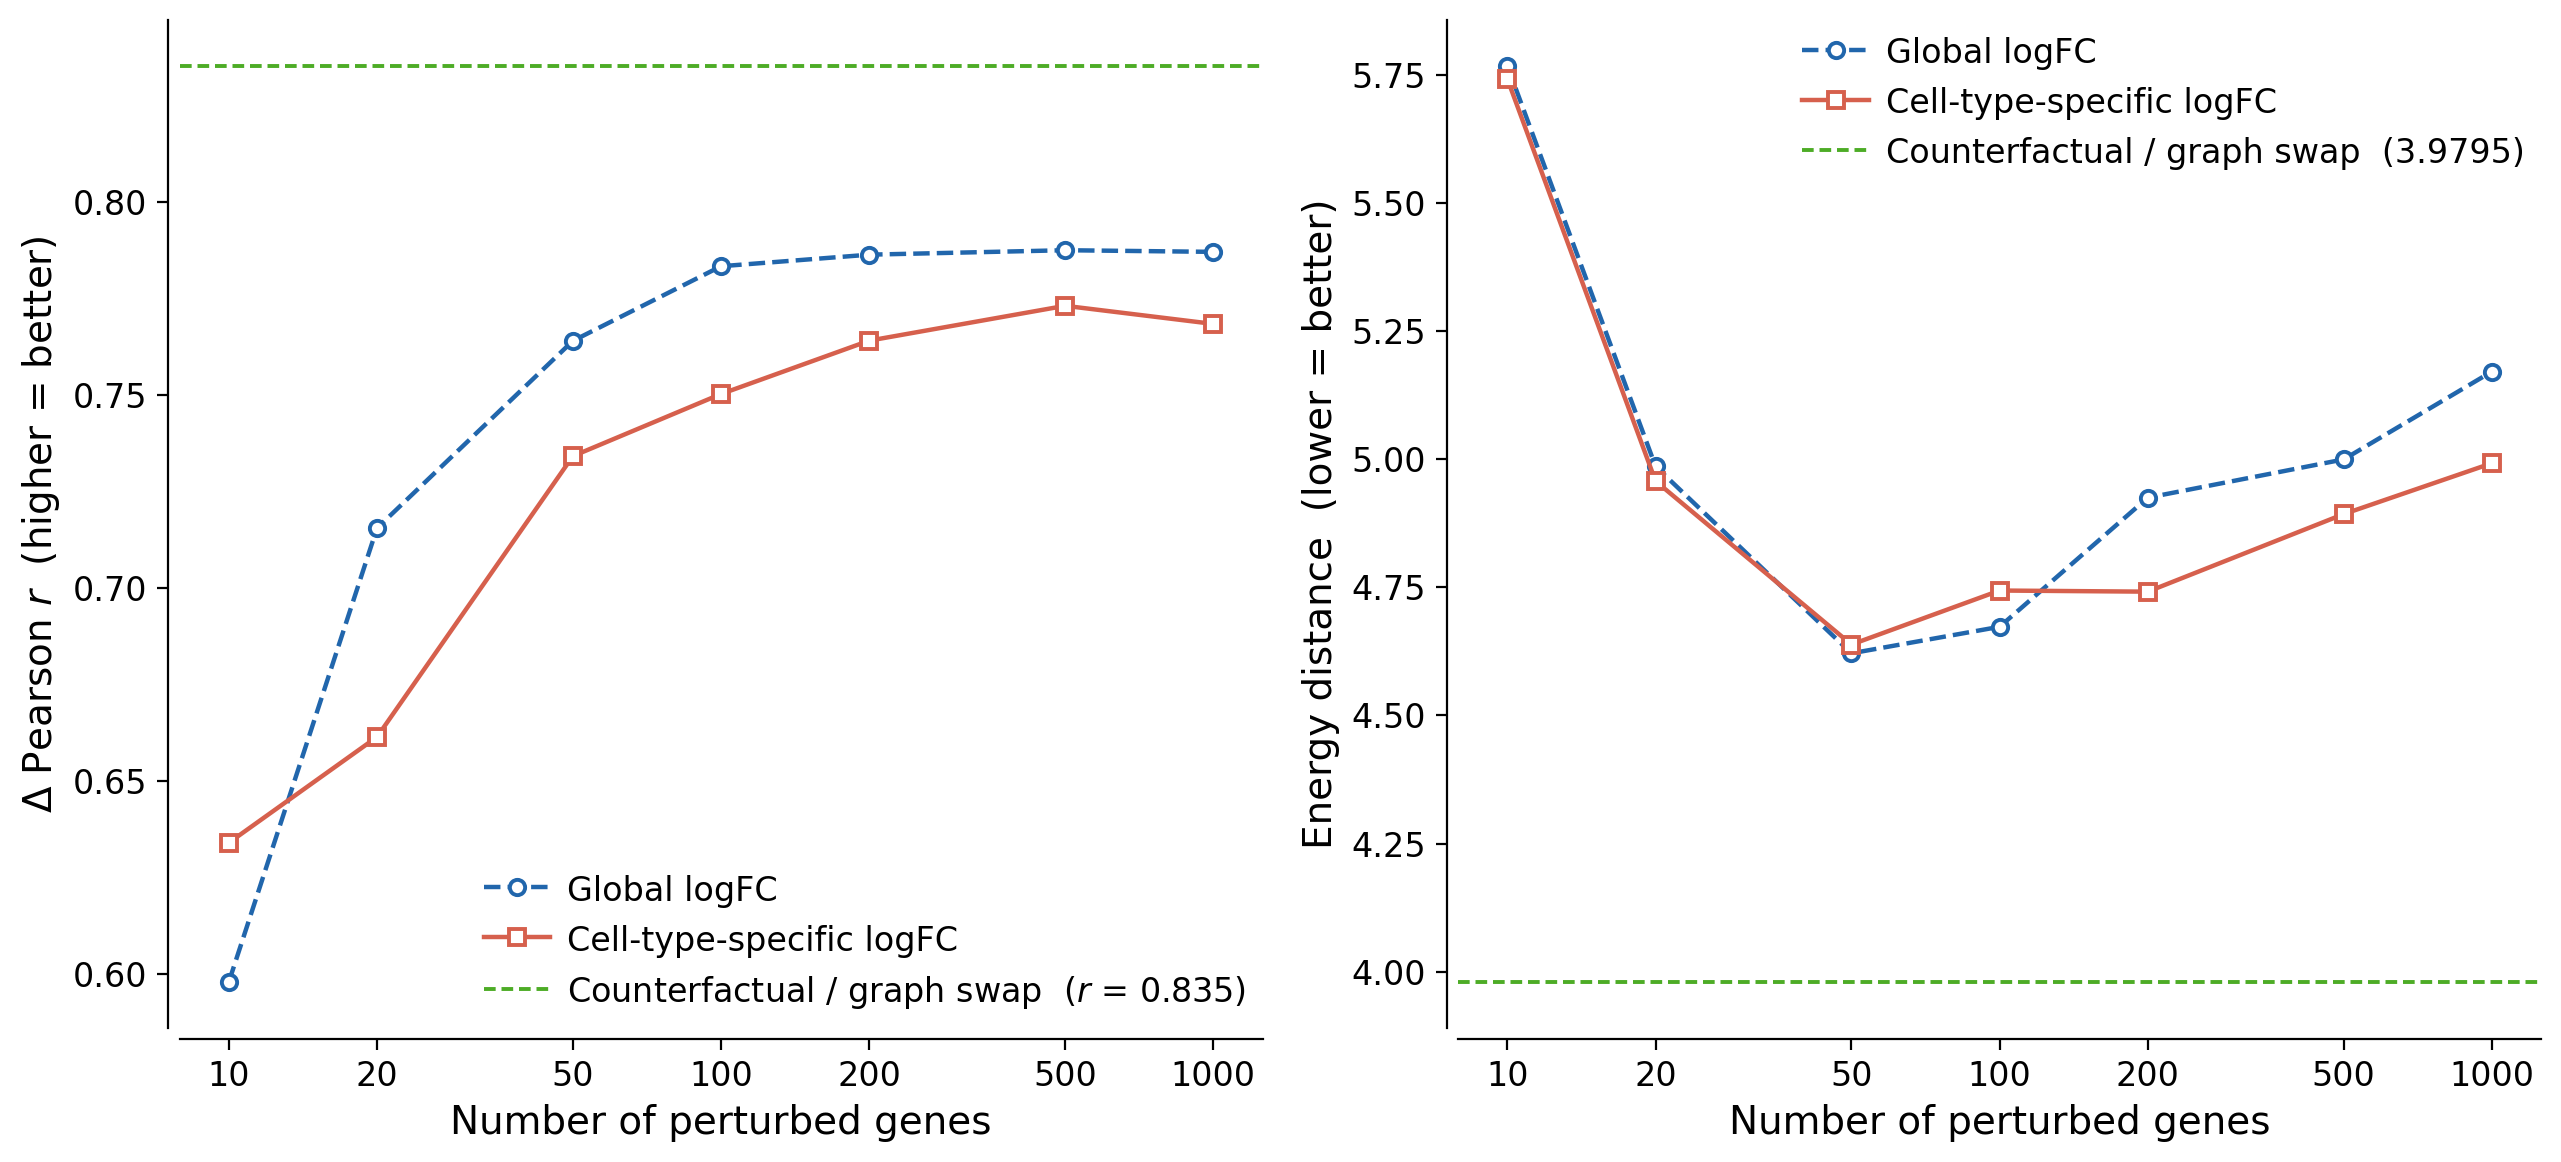

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Nature-style rcParams ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

# Nature palette — muted, print-friendly
BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Left panel: Pearson r ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(
    top_n_perturb_values, global_results,
    color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Global logFC',
    zorder=3,
)
ax.plot(
    top_n_perturb_values, ctspec_results,
    color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Cell-type-specific logFC',
    zorder=3,
)
ax.axhline(
    cf_avg_pearson,
    color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
    label=f'Counterfactual / graph swap  ($r$ = {cf_avg_pearson:.3f})',
    zorder=2,
)
ax.set_xscale('log')
ax.set_xticks(top_n_perturb_values)
ax.set_xticklabels([str(v) for v in top_n_perturb_values])
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_xlabel('Number of perturbed genes', fontsize=14)
ax.set_ylabel('Δ Pearson $r$  (higher = better)', fontsize=14)
ax.spines['left'].set_position(('outward', 4))
ax.spines['bottom'].set_position(('outward', 4))
ax.legend(frameon=False, handlelength=2.0)

# ── Right panel: Energy distance ──────────────────────────────────────────
ax2 = axes[1]
ax2.plot(
    top_n_perturb_values, global_edist_results,
    color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Global logFC',
    zorder=3,
)
ax2.plot(
    top_n_perturb_values, ctspec_edist_results,
    color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Cell-type-specific logFC',
    zorder=3,
)
ax2.axhline(
    cf_avg_edistance,
    color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
    label=f'Counterfactual / graph swap  ({cf_avg_edistance:.4f})',
    zorder=2,
)
ax2.set_xscale('log')
ax2.set_xticks(top_n_perturb_values)
ax2.set_xticklabels([str(v) for v in top_n_perturb_values])
ax2.xaxis.set_minor_locator(ticker.NullLocator())
ax2.set_xlabel('Number of perturbed genes', fontsize=14)
ax2.set_ylabel('Energy distance  (lower = better)', fontsize=14)
ax2.spines['left'].set_position(('outward', 4))
ax2.spines['bottom'].set_position(('outward', 4))
ax2.legend(frameon=False, handlelength=2.0)

fig.tight_layout()
# plt.savefig(save_fig, bbox_inches='tight')
plt.show()
